# Метод 2 — MLP. Часть 2: обучение

Для каждой из 6 потерь (`mse`, `mae`, `huber`, `msle`, `rmsle`, `smlar_smooth`):
- На внутреннем 75/25 сплите train подбирается лучший чекпойнт по SMLAR на val.

In [2]:
from pathlib import Path
import sys

ROOT = Path('/Users/ensamsanovich/auc_forecast')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

OUT_DIR = ROOT / 'outputs' / 'method_2_mlp'
OUT_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from core.config import SEED, ALPHA, INNER_CALIB_FRAC, MODEL_DIR, TARGETS, set_seed
from core.runner import load_unified_data
from core.leak_safe_features import build_leak_safe_aggregates
from core.metrics import LOSS_REGISTRY, smlar, smlar_per_target, monotonicity_violation
from core.ci import seeded_train_calib_split

set_seed(SEED)
data = load_unified_data()
split = data['split']
X = build_leak_safe_aggregates(data['val'], data['user_index'], data['pub_index'])
y = data['ans'][list(TARGETS)].astype(float)
train_idx = split['train_idx']
holdout_idx = split['holdout_idx']
print('X shape:', X.shape, '| y shape:', y.shape)


X shape: (1008, 39) | y shape: (1008, 3)


In [7]:
class ImprovedMLP(nn.Module):
    def __init__(self, input_dim, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(128, 64),  nn.BatchNorm1d(64),  nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(64, 3), nn.Sigmoid(),
        )
    def forward(self, x):
        return self.net(x)


def _standardize(X_tr, X_te):
    mu = X_tr.mean(axis=0); sd = X_tr.std(axis=0) + 1e-6
    return (X_tr - mu) / sd, (X_te - mu) / sd, mu, sd


def _train_one(X_tr, y_tr, X_va, y_va, loss_name,
                epochs=250, patience=20, batch_size=64, lr=1e-3, wd=1e-4):
    set_seed(SEED)
    model = ImprovedMLP(input_dim=X_tr.shape[1])
    loss_fn = LOSS_REGISTRY[loss_name]()
    optim = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    Xtr_t = torch.tensor(X_tr, dtype=torch.float32)
    ytr_t = torch.tensor(y_tr, dtype=torch.float32)
    Xva_t = torch.tensor(X_va, dtype=torch.float32)
    yva_t = torch.tensor(y_va, dtype=torch.float32)
    loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=batch_size, shuffle=True)
    best_val = float('inf'); bad = 0; history = []; best_state = None
    for ep in range(epochs):
        model.train()
        for xb, yb in loader:
            optim.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward(); optim.step()
        model.eval()
        with torch.no_grad():
            pred_va = model(Xva_t).cpu().numpy()
        v = smlar(yva_t.numpy(), pred_va)
        history.append(v)
        if v < best_val - 1e-3:
            best_val = v; bad = 0
            best_state = {k: t.detach().clone() for k, t in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience: break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


def _predict_np(model, X):
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(X, dtype=torch.float32)).cpu().numpy()


In [8]:
X_tr_all = X.iloc[train_idx].values
y_tr_all = y.iloc[train_idx].values
X_ho = X.iloc[holdout_idx].values
y_ho = y.iloc[holdout_idx].values

sub_local, cal_local = seeded_train_calib_split(len(train_idx), INNER_CALIB_FRAC, SEED)
X_sub = X_tr_all[sub_local]
y_sub = y_tr_all[sub_local]
X_cal = X_tr_all[cal_local]
y_cal = y_tr_all[cal_local]

X_sub_s, X_cal_s, mu, sd = _standardize(X_sub, X_cal)
X_ho_s = (X_ho - mu) / sd
print('Внутренний sub-train:', X_sub_s.shape, '| cal:', X_cal_s.shape, '| holdout:', X_ho_s.shape)


Внутренний sub-train: (604, 39) | cal: (202, 39) | holdout: (202, 39)


## Прогон всех 6 функций потерь

In [9]:
import time
import matplotlib.pyplot as plt

losses_to_try = ['mse', 'mae', 'huber', 'msle', 'rmsle', 'smlar_smooth']
results = {}

for loss_name in losses_to_try:
    t0 = time.time()
    model, history = _train_one(X_sub_s, y_sub, X_cal_s, y_cal, loss_name)
    pred_cal = np.clip(_predict_np(model, X_cal_s), 0.0, 1.0)
    pred_ho  = np.clip(_predict_np(model, X_ho_s),  0.0, 1.0)
    s_cal = smlar(y_cal, pred_cal)
    s_ho  = smlar(y_ho,  pred_ho)
    results[loss_name] = {
        'history': history,
        'smlar_cal': float(s_cal),
        'smlar_ho':  float(s_ho),
        'pred_ho':   pred_ho,
        'model':     model,
    }
    print(f'  {loss_name:14s}  cal SMLAR={s_cal:6.2f}%  holdout SMLAR={s_ho:6.2f}% ')

    fig, ax = plt.subplots(figsize=(7.2, 4.0))
    ax.plot(range(1, len(history) + 1), history, marker='o', linewidth=1.6, color='#2a6fb8')
    ax.set_xlabel('Эпоха')
    ax.set_ylabel('SMLAR на cal-выборке, %')
    ax.set_title(f'Кривая обучения — {loss_name}')
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(OUT_DIR / f'fig_loss_{loss_name}.png', dpi=120, bbox_inches='tight')
    plt.close(fig)


  mse             cal SMLAR= 51.61%  holdout SMLAR= 55.38% 
  mae             cal SMLAR= 37.86%  holdout SMLAR= 40.56% 
  huber           cal SMLAR= 46.54%  holdout SMLAR= 52.54% 
  msle            cal SMLAR= 26.47%  holdout SMLAR= 27.32% 
  rmsle           cal SMLAR= 36.65%  holdout SMLAR= 37.88% 
  smlar_smooth    cal SMLAR= 25.44%  holdout SMLAR= 26.50% 


## Кривые обучения

In [15]:
colors = ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#1f77b4', '#9467bd']
for k in range(1, len(losses_to_try) + 1):
    fig, ax = plt.subplots(figsize=(8.0, 4.6))
    for j, name in enumerate(losses_to_try[:k]):
        hist = results[name]['history']
        ax.plot(range(1, len(hist) + 1), hist, label=name, color=colors[j], linewidth=1.6)
    ax.set_xlabel('Эпоха')
    ax.set_ylabel('SMLAR на cal-выборке, %')
    ax.set_title(f'Сравнение функций потерь — кадр {k}/{len(losses_to_try)}')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=9)
    fig.tight_layout()
    fig.savefig(OUT_DIR / f'fig_compare_step_{k:03d}.png', dpi=120, bbox_inches='tight')
    plt.close(fig)
print('Сохранено кадров сравнения:', len(losses_to_try))


Сохранено кадров сравнения: 6


In [11]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)
winner_model = results['smlar_smooth']['model']
winner_path = MODEL_DIR / 'best_mlp_smlar_smooth.pt'
torch.save(winner_model.state_dict(), winner_path)
print('Сохранён state_dict победителя:', winner_path)


Сохранён state_dict победителя: /Users/ensamsanovich/auc_forecast/model/best_mlp_smlar_smooth.pt


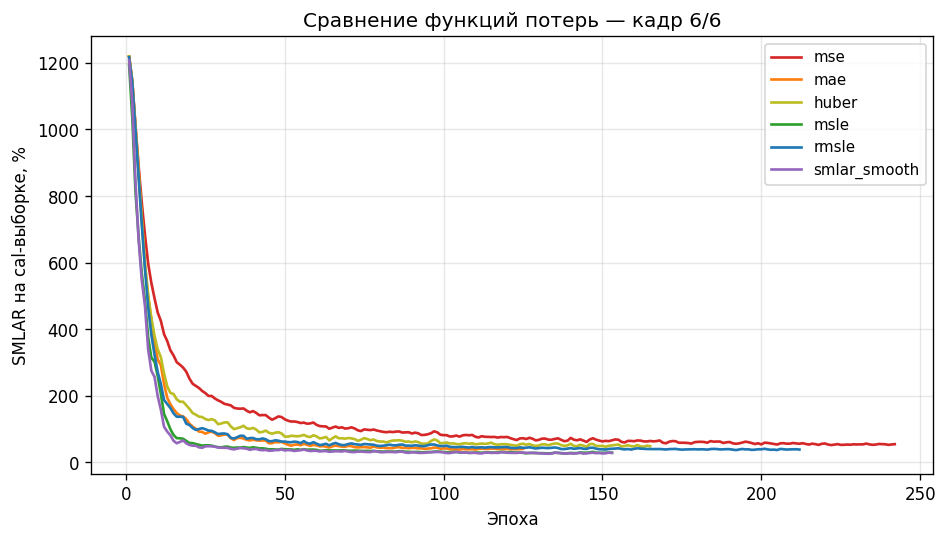

In [14]:
from IPython.display import Image, display

for k in range(len(losses_to_try), len(losses_to_try) + 1):
    display(Image(filename=OUT_DIR / f'fig_compare_step_{k:03d}.png'))

- Победитель (`smlar_smooth`) сохраняется в `model/best_mlp_smlar_smooth.pt`.
- Сохраняется кривая обучения и SMLAR на holdout.